# Image Score Redistribution (Chains Strategy)
This notebook rebalances image scores using chains derived from comparison history.
Each chain maps its best -> worst item to scores 1.0 -> 0.0. Chains are applied from shorter to longer, so long chains will overwrite earlier short-chain assignments.

Options: toggle `UPDATE_DATABASE`, `MOVE_FILES`, `DRY_RUN`.

In [ ]:
import os
import sys
from pathlib import Path

# The notebook is in external_modules/step01ranking_new/
# We need to add the plugin root (comfyui-image-scorer/) to sys.path to find 'shared'
notebook_path = Path(os.getcwd()).resolve()
plugin_root = notebook_path.parents[1]
print(f"Plugin root: {plugin_root}")

if str(plugin_root) not in sys.path:
    sys.path.insert(0, str(plugin_root))

# Also ensure the current folder is in path for relative imports
if str(notebook_path) not in sys.path:
    sys.path.insert(0, str(notebook_path))

print(f"Current working directory: {os.getcwd()}")


Plugin root: E:\ComfyUI\custom_nodes\comfyui-image-scorer
Current working directory: e:\ComfyUI\custom_nodes\comfyui-image-scorer\external_modules\step01ranking_new


In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

# Import local modules
from database.images_table import get_all_images, update_image_score_confidence
from database.comparisons_table import get_all_comparisons
from file_management.path_handler import (
    get_ranked_root,
    compute_path_from_filename,
    find_image_path,
    sync_image_metadata_to_json,
)
from image_processor import ImageProcessor


In [ ]:
# --- CONFIGURATION ---
UPDATE_DATABASE = False  # Set to True to save new scores to DB
MOVE_FILES = False  # Set to True to move files to new folders
DRY_RUN = True  # If True, no changes are actually made
PLOT_BINS = 50  # Number of bins for the histogram
# Safety limits for chain enumeration (tune if dataset is large)
MAX_CHAIN_DEPTH = 50
MAX_CHAINS = 200000
# ---------------------


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='e:\\ComfyUI\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralBol.ttf', name='STIXGeneral', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='e:\\ComfyUI\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizTwoSymBol.ttf', name='STIXSizeTwoSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='e:\\ComfyUI\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\

Fetching images from database...


DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='e:\\ComfyUI\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralBol.ttf', name='STIXGeneral', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='e:\\ComfyUI\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizTwoSymBol.ttf', name='STIXSizeTwoSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='e:\\ComfyUI\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(Font

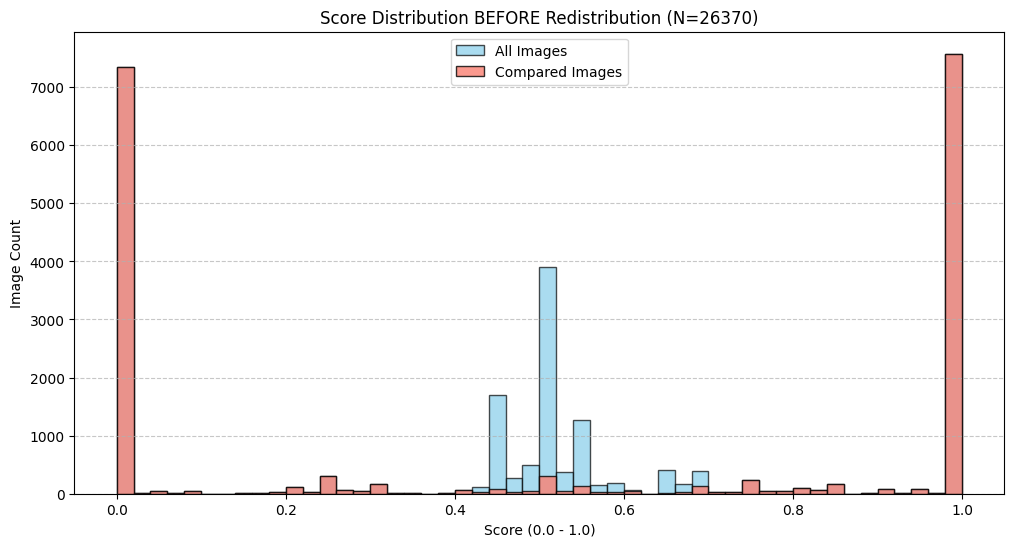

In [ ]:
print("Fetching images from database...")

all_images = get_all_images()
compared_images = [img for img in all_images if img.get("comparison_count", 0) > 0]
if not all_images:
    print("No images found!")
else:
    before_scores = [img.get("score", 0.0) for img in all_images]
    compared_scores = [img.get("score", 0.0) for img in compared_images]
    plt.figure(figsize=(12, 6))
    plt.hist(
        before_scores,
        bins=PLOT_BINS,
        color="skyblue",
        edgecolor="black",
        alpha=0.7,
        label="All Images",
    )
    plt.hist(
        compared_scores,
        bins=PLOT_BINS,
        color="salmon",
        edgecolor="black",
        alpha=0.8,
        label="Compared Images",
    )
    plt.title(f"Score Distribution BEFORE Redistribution (N={len(all_images)})")
    plt.xlabel("Score (0.0 - 1.0)")
    plt.ylabel("Image Count")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend()
    plt.show()


In [ ]:
# Build chains from comparison history and apply them (short -> long)
from collections import defaultdict, Counter

print("Fetching comparisons from database (direct comparisons only, weight==1.0)...")
all_comps = [c for c in get_all_comparisons() if float(c.get("weight", 1.0)) == 1.0]

# Build adjacency list: winner -> unique losers (preserve insertion order)
adj = defaultdict(list)
nodes = set()
for c in all_comps:
    a = c.get("filename_a")
    b = c.get("filename_b")
    winner = c.get("winner")
    if not a or not b or not winner:
        continue
    if winner == a:
        loser = b
    elif winner == b:
        loser = a
    else:
        continue
    # avoid immediate duplicates
    if loser not in adj[winner]:
        adj[winner].append(loser)
    nodes.add(winner)
    nodes.add(loser)

print(
    f"Nodes in comparison graph: {len(nodes)} | edges (approx): {sum(len(v) for v in adj.values())}"
)


Fetching comparisons from database (direct comparisons only, weight==1.0)...
Nodes in comparison graph: 17832 | edges (approx): 9108


In [ ]:
# Enumerate simple chains (paths) using iterative DFS.
# We collect all chains (length>=2).
chains = []
chain_lengths = Counter()
stack = []
for start in list(nodes):
    stack.append((start, [start]))
    while stack and len(chains) < MAX_CHAINS:
        node, path = stack.pop()
        # extend neighbors
        for nb in adj.get(node, []):
            if nb in path:
                continue
            newpath = path + [nb]
            if len(newpath) >= 2:
                chains.append(newpath)
                chain_lengths[len(newpath)] += 1
            if len(newpath) < MAX_CHAIN_DEPTH:
                stack.append((nb, newpath))
        # safety break
        if len(chains) >= MAX_CHAINS:
            break

print(
    f"Found {len(chains)} chains (capped at {MAX_CHAINS}). Distinct chain lengths: {len(chain_lengths)}"
)


Found 9226 chains (capped at 200000). Distinct chain lengths: 3


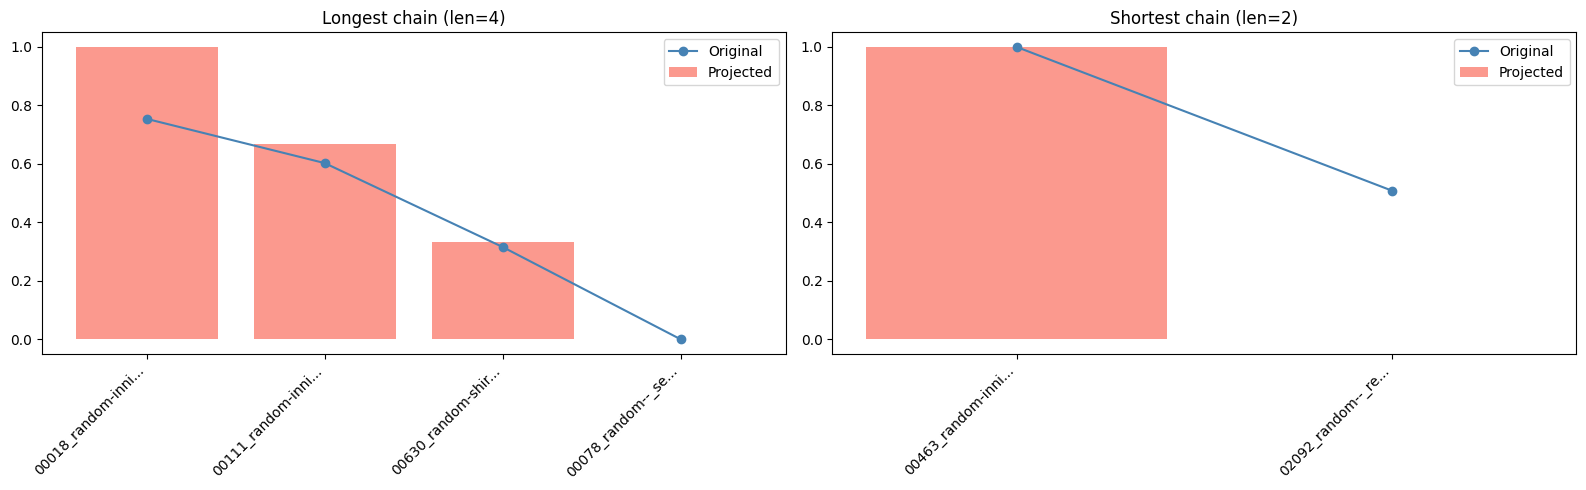

Longest chain (filename, projected, original):
00018_random-innievag-SD15_cyberreali...  projected=1.000  original=0.754
00111_random-innievag-SD15_cyberreali...  projected=0.667  original=0.603
00630_random-shirtliftv1-SD15_realist...  projected=0.333  original=0.316
00078_random--_sexyBabes_v10.png          projected=0.000  original=0.000

Shortest chain (filename, projected, original):
00463_random-innievag-SD15_realisticV...  projected=1.000  original=1.000
02092_random--_realisticLazyMixNSFW_v...  projected=0.000  original=0.508


In [ ]:
# Show shortest and longest chains with projected and original scores
valid_chains = [c for c in chains if len(c) >= 2]
if not valid_chains:
    print("No chains found.")
else:
    lengths = [len(c) for c in valid_chains]
    min_len = min(lengths)
    max_len = max(lengths)
    shortest_chain = next(c for c in valid_chains if len(c) == min_len)
    # pick one of the longest chains (reverse for likely longer recent chains)
    longest_chain = next(c for c in reversed(valid_chains) if len(c) == max_len)

    original_scores_map = {
        img["filename"]: float(img.get("score", 0.0)) for img in all_images
    }

    def abbrev(name, n=30):
        base = os.path.basename(name)
        return base if len(base) <= n else base[: n - 3] + "..."

    def chain_table(chain):
        L = len(chain)
        projected = [1.0 - (i / (L - 1)) for i in range(L)]
        original = [original_scores_map.get(f, 0.0) for f in chain]
        lines = []
        for fname, proj, orig in zip(chain, projected, original):
            lines.append(
                f"{abbrev(fname, 40):40}  projected={proj:0.3f}  original={orig:0.3f}"
            )
        return lines, projected, original

    import matplotlib.pyplot as plt

    if min_len != max_len:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        # Longest
        lines_long, proj_long, orig_long = chain_table(longest_chain)
        x_long = range(len(longest_chain))
        axes[0].bar(x_long, proj_long, color="salmon", alpha=0.8, label="Projected")
        axes[0].plot(x_long, orig_long, marker="o", color="steelblue", label="Original")
        axes[0].set_xticks(x_long)
        axes[0].set_xticklabels(
            [abbrev(f, 20) for f in longest_chain], rotation=45, ha="right"
        )
        axes[0].set_ylim(-0.05, 1.05)
        axes[0].set_title(f"Longest chain (len={len(longest_chain)})")
        axes[0].legend()

        # Shortest
        lines_short, proj_short, orig_short = chain_table(shortest_chain)
        x_short = range(len(shortest_chain))
        axes[1].bar(x_short, proj_short, color="salmon", alpha=0.8, label="Projected")
        axes[1].plot(
            x_short, orig_short, marker="o", color="steelblue", label="Original"
        )
        axes[1].set_xticks(x_short)
        axes[1].set_xticklabels(
            [abbrev(f, 20) for f in shortest_chain], rotation=45, ha="right"
        )
        axes[1].set_ylim(-0.05, 1.05)
        axes[1].set_title(f"Shortest chain (len={len(shortest_chain)})")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        print("Longest chain (filename, projected, original):")
        for l in lines_long:
            print(l)
        print("\nShortest chain (filename, projected, original):")
        for l in lines_short:
            print(l)
    else:
        # all chains same length; show one
        lines, proj, orig = chain_table(longest_chain)
        plt.figure(figsize=(10, 4))
        x = range(len(longest_chain))
        plt.bar(x, proj, color="salmon", alpha=0.8, label="Projected")
        plt.plot(x, orig, marker="o", color="steelblue", label="Original")
        plt.xticks(x, [abbrev(f, 20) for f in longest_chain], rotation=45, ha="right")
        plt.ylim(-0.05, 1.05)
        plt.title(f"Chain (len={len(longest_chain)})")
        plt.legend()
        plt.tight_layout()
        plt.show()
        print("Chain (filename, projected, original):")
        for l in lines:
            print(l)


Applying chains:   0%|          | 0/9226 [00:00<?, ?it/s]

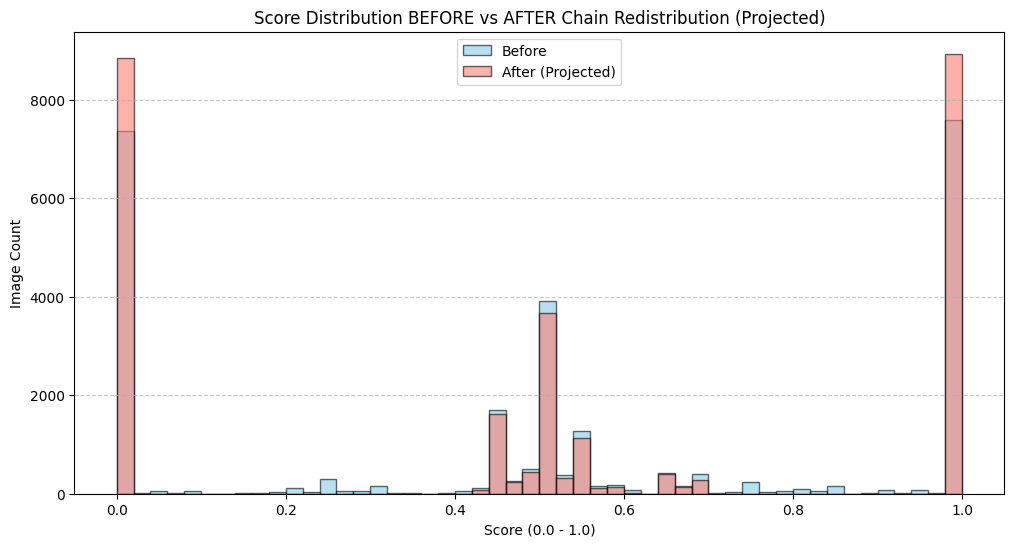

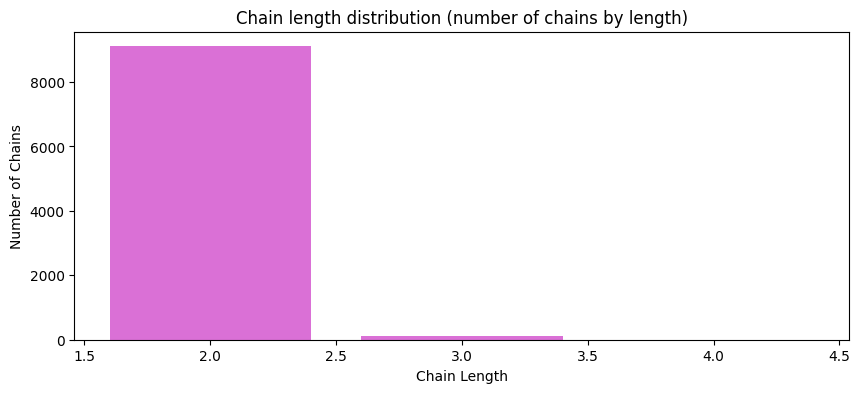

Top 10 longest chain lengths: [4, 4, 4, 3, 3, 3, 3, 3, 3, 3]
Top 10 most-overwritten images (filename, times): [('00483_random--cyberrealisticPony_v160.png', 17), ('00392_random-add_detail-SD15_uberRealisticPornMerge_v23Final.png', 9), ('00256_random-PSCowgirl-SD15_realisticVisionV60B1_v51HyperVAE.png', 9), ('00011_random-innievag-realisticVisionV60B1_v51HyperVAE.png', 9), ('00363_random--_sexyBabes_v10.png', 9), ('00490_random-shirtliftv1-SD15_lazymixRealAmateur_v40.png', 9), ('00093_random-PSCowgirl-lazymixRealAmateur_v40.png', 7), ('00105_random-add_detail-lazymixRealAmateur_v40.png', 7), ('00058_random-shirtliftv1-dreamshaper_8.png', 7), ('01019_random--_sexyBabes_v10.png', 7)]


In [ ]:
# Sort chains by length ascending (short -> long)
chains.sort(key=len)

# Apply chains sequentially. For each chain, best (first) -> 1.0, worst (last) -> 0.0
scores_by_filename = {
    img["filename"]: float(img.get("score", 0.0)) for img in all_images
}
chain_apply_counts = Counter()

for chain in tqdm(chains, desc="Applying chains"):
    length = len(chain)
    if length <= 1:
        continue
    for idx, fname in enumerate(chain):
        projected_score = 1.0 - (idx / (length - 1))
        scores_by_filename[fname] = float(projected_score)
        chain_apply_counts[fname] += 1

# Prepare updates list to match existing notebook format (use 'score' key)
updates = []
for img in all_images:
    fname = img["filename"]
    old_score = float(img.get("score", 0.0))
    score = float(scores_by_filename.get(fname, old_score))
    updates.append(
        {
            "filename": fname,
            "old_score": old_score,
            "score": score,
            "confidence": float(img.get("confidence", 0.0)),
            "count": int(img.get("comparison_count", 0)),
        }
    )

# Plot projected distribution after chains applied (overlay BEFORE/AFTER)
after_scores = [up["score"] for up in updates]
plt.figure(figsize=(12, 6))
plt.hist(
    before_scores,
    bins=PLOT_BINS,
    color="skyblue",
    edgecolor="black",
    alpha=0.6,
    label="Before",
)
plt.hist(
    after_scores,
    bins=PLOT_BINS,
    color="salmon",
    edgecolor="black",
    alpha=0.6,
    label="After (Projected)",
)
plt.title("Score Distribution BEFORE vs AFTER Chain Redistribution (Projected)")
plt.xlabel("Score (0.0 - 1.0)")
plt.ylabel("Image Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()
plt.show()

# Chain length distribution
if chain_lengths:
    lengths, counts = zip(*sorted(chain_lengths.items()))
    plt.figure(figsize=(10, 4))
    plt.bar(lengths, counts, color="orchid")
    plt.title("Chain length distribution (number of chains by length)")
    plt.xlabel("Chain Length")
    plt.ylabel("Number of Chains")
    plt.show()

# Diagnostics
top_chains = sorted(chains, key=len, reverse=True)[:10]
print("Top 10 longest chain lengths:", [len(c) for c in top_chains])
most_applied = chain_apply_counts.most_common(10)
print("Top 10 most-overwritten images (filename, times):", most_applied)


In [ ]:
# Commit updates to DB and optionally move files based on new scores
if UPDATE_DATABASE:
    if DRY_RUN:
        print(f"[DRY RUN] Would update database scores for {len(updates)} images.")
    else:
        print(f"Updating database for {len(updates)} images...")
        for up in tqdm(updates, desc="Updating DB"):
            update_image_score_confidence(
                up["filename"], up["score"], up["confidence"], up["count"]
            )
else:
    print("Database update skipped (UPDATE_DATABASE = False).")

if MOVE_FILES:
    moved = 0
    errors = 0

    for up in tqdm(updates, desc="Relocating files"):
        fname = up["filename"]
        current = find_image_path(fname)
        if not current:
            continue

        # Compute target based on the score
        target = compute_path_from_filename(fname, up["score"])

        if current != target:
            if DRY_RUN:
                moved += 1
            else:
                try:
                    ok = sync_image_metadata_to_json(
                        fname, up["score"], up["confidence"], up["count"]
                    )
                    if ok:
                        moved += 1
                    else:
                        errors += 1
                except Exception:
                    errors += 1

    verb = "Would move" if DRY_RUN else "Moved"
    print(f"{verb} {moved} files. Errors: {errors}")
else:
    print("File movement skipped (MOVE_FILES = False).")

print("Done.")


Database update skipped (UPDATE_DATABASE = False).
File movement skipped (MOVE_FILES = False).
Done.
